### Step 1: Data Collection

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
image_paths = [
    "data/train/train1.jpg",
    "data/train/train2.jpg",
    "data/train/train3.jpg",
    "data/train/train4.jpg",
    "data/train/train5.jpg",
    "data/train/train6.jpg",
    "data/train/train7.jpg",
    "data/train/train8.jpg",
    "data/train/train9.jpg",
    "data/train/train10.jpg",
    "data/train/train11.jpg",
    "data/train/train12.jpg",
    "data/train/train13.jpg",
    "data/train/train14.jpg",
    "data/train/train15.jpg",
    "data/train/train16.jpg",
    "data/train/train17.jpg",
    "data/train/train18.jpg",
    "data/train/train19.jpg",
    "data/train/train20.jpg"  ]
  

images = []

for path in image_paths:
    img = cv2.imread(path)
    
    if img is not None:
        images.append(img)

print("Loaded images:", len(images))

Loaded images: 20


### Step 02 : Convert to Chromaticity Space

chromaticity_images = []

for img in images:
    
    # Convert BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]
    
    sum_rgb = R + G + B
    sum_rgb[sum_rgb == 0] = 1
    
    r = R / sum_rgb
    g = G / sum_rgb
    
    chromaticity_images.append((r, g))
    
print("Chromaticity conversion done for all images")

In [32]:
chromaticity_images = []

for img in images:
    # Convert BGR to RGB and then to float32
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

    height, width, _ = img_rgb.shape

    r = np.zeros((height, width), dtype=np.float32)
    g = np.zeros((height, width), dtype=np.float32)

    for x in range(height):
        for y in range(width):
            R = img_rgb[x, y, 0]
            G = img_rgb[x, y, 1]
            B = img_rgb[x, y, 2]

            total = R + G + B

            if total == 0:
                total = 1

            r[x, y] = R / total
            g[x, y] = G / total

    chromaticity_images.append((r, g))

print("Chromaticity conversion completed")

Chromaticity conversion completed


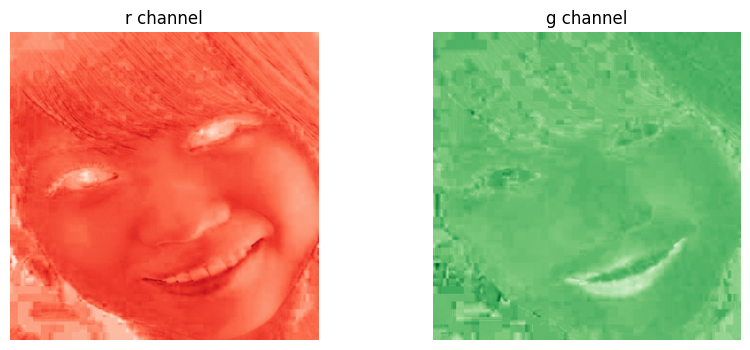

In [33]:
r, g = chromaticity_images[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(r, cmap="Reds")
plt.title("r channel")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(g, cmap="Greens")
plt.title("g channel")
plt.axis("off")

plt.show()

### Step 3: Skin Region Selection

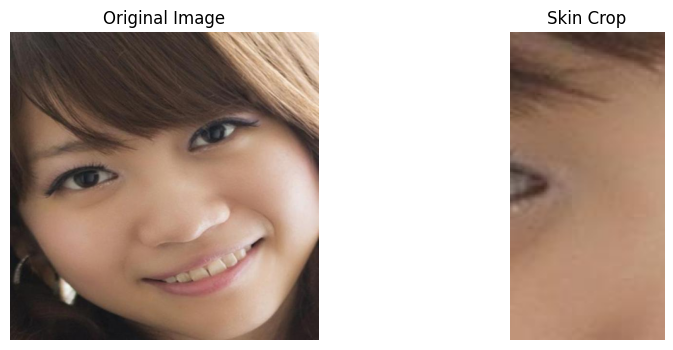

In [35]:
# Take one image
img = images[0]

# Convert to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Crop skin region (adjust these values)
skin_crop = img_rgb[200:400, 200:300]

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(skin_crop)
plt.title("Skin Crop")
plt.axis("off")

plt.show()

In [31]:
skin_crops = []

# Make sure crop_values length = number of images
crop_values = [
    (260, 430, 120, 300),
    (200, 350, 100, 250),
    (220, 380, 130, 290),
    # add ALL 20 crops
]

# Loop through original images (NOT chromaticity_images)
for i in range(len(images)):
    
    img = images[i]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    x1, x2, y1, y2 = crop_values[i]
    
    crop = img_rgb[x1:x2, y1:y2]
    
    skin_crops.append(crop)

print("Total crops:", len(skin_crops))

IndexError: list index out of range